# 06 — Classification Evaluation

**Covers concept IDs:** E1, E2, E3, E4, E5, E6, E7.

## Learning outcomes
1. Build a confusion matrix at any threshold $t$ from predicted probabilities and true labels.
2. Compute accuracy, sensitivity (TPR), specificity (TNR), precision from the four cells.
3. Build an ROC curve by sweeping the threshold through the sorted predicted probabilities.
4. Interpret AUC probabilistically.
5. Derive the profit-maximising threshold from an action-cost (or profit) matrix.
6. State the direction of sensitivity / specificity as the threshold moves.

## 1. The confusion matrix

With predicted labels $\hat y_i = \mathbb 1(\hat p_i > t)$:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

Totals: $n_P = TP + FN$ (positives), $n_N = TN + FP$ (negatives).

### The six rates

| Name | Formula |
|---|---|
| Accuracy | $(TP + TN)/n$ |
| Sensitivity = TPR = Recall | $TP/n_P$ |
| Specificity = TNR | $TN/n_N$ |
| FPR = $1-$TNR | $FP/n_N$ |
| FNR = $1-$TPR | $FN/n_P$ |
| Precision = PPV | $TP/(TP+FP)$ |

**Mnemonic.** Sensitivity/TPR is *within the positives*. Specificity/TNR is *within the negatives*. Precision is *within the "predict 1"s*.

## 2. Worked example — practice problem Concept Check 2

Confusion matrix:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 | 80 | 20 |
| Actual 1 | 30 | 70 |

- TN = 80, FP = 20, FN = 30, TP = 70.
- $n=200$, $n_P=100$, $n_N=100$.

**(a) Accuracy.** $(70+80)/200 = 150/200 = 0.75$.

**(b) Sensitivity.** $TP/n_P = 70/100 = 0.70$.

**(c) Specificity.** $TN/n_N = 80/100 = 0.80$.

## 3. ROC curve — point-by-point construction

Algorithm (review slide 17):
1. Sort observations by predicted probability $\hat p_i$, descending.
2. Sweep the threshold $t$ from $1 \to 0$.
3. For each candidate threshold, classify $\hat y_i = \mathbb 1(\hat p_i > t)$ and compute (FPR, TPR).
4. Plot TPR vs FPR.

### Hand example — the slide-17 10-point table
| $i$ | $y_i$ | $\hat p_i$ |
|---|---|---|
| 1 | 1 | 0.92 |
| 2 | 0 | 0.83 |
| 3 | 1 | 0.78 |
| 4 | 1 | 0.61 |
| 5 | 0 | 0.55 |
| 6 | 1 | 0.44 |
| 7 | 0 | 0.37 |
| 8 | 1 | 0.21 |
| 9 | 0 | 0.18 |
| 10 | 0 | 0.09 |

Totals: $n_P = 5$ (rows 1,3,4,6,8), $n_N = 5$ (rows 2,5,7,9,10).

Walking the threshold from high to low:

| threshold just below $\hat p_i$ | predicts 1 | TP | FP | TPR | FPR |
|---|---|---|---|---|---|
| 0.92 | {1} | 1 | 0 | 0.2 | 0.0 |
| 0.83 | {1,2} | 1 | 1 | 0.2 | 0.2 |
| 0.78 | {1,2,3} | 2 | 1 | 0.4 | 0.2 |
| 0.61 | {1,2,3,4} | 3 | 1 | 0.6 | 0.2 |
| 0.55 | + row 5 | 3 | 2 | 0.6 | 0.4 |
| 0.44 | + row 6 | 4 | 2 | 0.8 | 0.4 |
| 0.37 | + row 7 | 4 | 3 | 0.8 | 0.6 |
| 0.21 | + row 8 | 5 | 3 | 1.0 | 0.6 |
| 0.18 | + row 9 | 5 | 4 | 1.0 | 0.8 |
| 0.09 | + row 10 | 5 | 5 | 1.0 | 1.0 |

Connect the (FPR, TPR) points — that's the ROC curve. This ranker is *very good*: it reaches TPR = 0.6 at FPR = 0.2 and TPR = 1 at FPR = 0.6.

## 4. AUC — three equivalent interpretations

$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \,d\text{FPR}$.

1. **Geometric.** Area under the ROC.
2. **Probabilistic.** $\Pr(\hat p_{i:y=1} > \hat p_{j:y=0})$ — the probability that a random positive outscores a random negative.
3. **Ranking.** The *Mann–Whitney U* statistic normalized to [0,1].

Benchmarks: 0.5 = chance; 0.7 = useful; 0.85+ = strong; 1.0 = perfect ranker. AUC is threshold-free — it measures how well the model *orders* observations, not how well it classifies at any given threshold.

## 5. Decision-theoretic threshold (E6)

Given an action ("send mailer", "offer tutoring", etc.) with costs and benefits depending on the true class, build an **action-payoff matrix**:

|  | True Y=1 | True Y=0 |
|---|---|---|
| Act | $+B_{TP}$ | $-C_{FP}$ |
| Don't | 0 | 0 |

Expected payoff from acting given $\hat p = P(Y=1\mid x)$:
$$\mathbb E[\text{act}\mid p] = B_{TP}\,p - C_{FP}(1-p).$$

Act iff this exceeds 0:
$$B_{TP}\,p - C_{FP}(1-p) > 0 \;\;\Leftrightarrow\;\; p > \frac{C_{FP}}{C_{FP} + B_{TP}}.$$

$$\boxed{\; t^\star = \frac{C_{FP}}{C_{FP}+B_{TP}}.\;}$$

Effect on rates:
- If $t^\star < 0.5$, you act more aggressively. Sensitivity↑, specificity↓.
- If $t^\star > 0.5$, you act more cautiously. Sensitivity↓, specificity↑.

### Example — Assignment 4 Q8 (mailer)
- Cost of sending: 0.50 per mailer ($C_{FP} = 0.50$).
- Net gain when a true Bud Light buyer is reached: 2.00 revenue – 0.50 send cost = **1.50** ($B_{TP} = 1.50$).
- $t^\star = 0.50 / (0.50 + 1.50) = \mathbf{0.25}$.

Lowering the threshold from 0.5 to 0.25 pushed sensitivity from 0.14 to 0.73 and dropped specificity from 0.95 to 0.47 — precisely the direction E6a predicts.

## 6. Example — practice problem 1.2.3 (tutoring)

Variables:
- $p$ = $P(\text{student completes}\mid x)$ under the logistic model.
- Assume *all* tutored students complete.

Payoff matrix (from review slide 16, $+$ means revenue, $-$ means cost):

|  | Completes w/o tutoring | Does not complete w/o tutoring |
|---|---|---|
| Tutor    | $-30$  | $+90$ (= $120 - 30$) |
| No tutor | $0$    | $-25$ |

$\mathbb E[\text{tutor}] = -30 p + 90(1-p)$.

$\mathbb E[\text{no tutor}] = 0\cdot p + (-25)(1-p) = -25(1-p)$.

Tutor iff $\mathbb E[\text{tutor}] > \mathbb E[\text{no tutor}]$:
$$-30 p + 90(1-p) > -25(1-p)$$
$$90 - 30p - 90p > -25 + 25p$$
$$90 - 120 p > -25 + 25p$$
$$115 > 145 p$$
$$p < \frac{115}{145} = \frac{23}{29} \approx 0.793.$$

$$\boxed{\;t^\star = 23/29 \approx 0.79.\;}$$

Tutor every student whose *predicted completion probability without tutoring* is below 0.79.

**Sensitivity / specificity consequences.** The default 0.5 threshold would tutor only students with $p<0.5$. Under the new threshold $p < 0.79$, we tutor a much larger group:
- Sensitivity for "non-completers" ↑ (we catch more of them).
- Specificity for "non-completers" ↓ (we also tutor some students who would have completed anyway).

## 7. Youden's J statistic (E7)

$J(t) = \text{TPR}(t) - \text{FPR}(t)$. The threshold $t^\star$ maximizing $J$ is the point on the ROC furthest above the 45° line — it balances sensitivity and specificity with equal weight. Useful when no asymmetric cost is specified.

## 8. Code demo — confusion matrix + ROC for the 10-point slide example

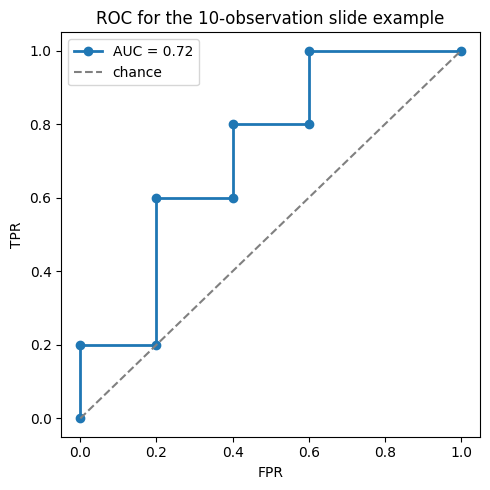

thresholds:  [ inf 0.92 0.83 0.61 0.55 0.44 0.37 0.21 0.09]
FPR:        [0.  0.  0.2 0.2 0.4 0.4 0.6 0.6 1. ]
TPR:        [0.  0.2 0.2 0.6 0.6 0.8 0.8 1.  1. ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y = np.array([1, 0, 1, 1, 0, 1, 0, 1, 0, 0])
p = np.array([0.92, 0.83, 0.78, 0.61, 0.55, 0.44, 0.37, 0.21, 0.18, 0.09])

fpr, tpr, thr = roc_curve(y, p)
auc_val = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, marker='o', lw=2, label=f'AUC = {auc_val:.2f}')
plt.plot([0,1],[0,1], ls='--', c='grey', label='chance')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC for the 10-observation slide example')
plt.legend(); plt.tight_layout(); plt.show()
print('thresholds: ', np.round(thr, 2))
print('FPR:       ', np.round(fpr, 2))
print('TPR:       ', np.round(tpr, 2))

## 9. Practice problems

### 9.1 Arithmetic
> Confusion matrix: TP=80, FP=20, FN=10, TN=90. Accuracy? TPR? TNR?

**Answer.** $n = 200$, $n_P = 90$, $n_N = 110$. Accuracy = 170/200 = 0.85; TPR = 80/90 ≈ 0.889; TNR = 90/110 ≈ 0.818.

### 9.2 Threshold direction
> A classifier has threshold 0.5. If we lower it to 0.3, what happens to sensitivity and specificity?

**Answer.** Sensitivity ↑ (more things predicted positive, including more true positives). Specificity ↓ (more false positives because we're more willing to predict 1).

### 9.3 Threshold derivation
> A classifier predicts $p$. Profit from correct positive = +200, cost of false positive = −100. Find $t^\star$.

**Answer.** $t^\star = C_{FP}/(C_{FP} + B_{TP}) = 100/(100 + 200) = 1/3 \approx 0.333.$

### 9.4 AUC interpretation
> A model reports AUC = 0.80. Interpret.

**Answer.** Given one random positive and one random negative, the model ranks the positive above the negative 80% of the time. Equivalently, the ROC covers 80% of the unit square.

### 9.5 Base rate
> The positive class has base rate 10%. A classifier reports sensitivity 0.2, specificity 0.97 at $t=0.5$. Is the classifier poorly-trained, or is this an expected consequence of the class imbalance?

**Answer.** Expected consequence. With a base rate that low, most predicted probabilities never exceed 0.5, so the default threshold predicts "0" for most observations — yielding high specificity and low sensitivity almost mechanically. The fix is to lower the threshold (using a cost-based formula or the base rate itself as a guide).

### 9.6 ROC construction
> Given $y = [1,1,0]$ and $\hat p = [0.9, 0.3, 0.7]$, compute the (FPR, TPR) pair at threshold $t=0.5$.

**Answer.** Predictions at $t=0.5$: $\hat y = [1,0,1]$.
- TP = 1 (i=1), FN = 1 (i=2), FP = 1 (i=3), TN = 0. $n_P=2,\ n_N=1$.
- TPR = 1/2 = 0.5.  FPR = 1/1 = 1.0.